In [120]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# Load Kaggle competition dataset (with fallback to local dataset)
try:
    import kagglehub
    path = kagglehub.competition_download("house-prices-advanced-regression-techniques")
    train_df = pd.read_csv(os.path.join(path, "train.csv"))
    print("Loaded dataset from Kaggle API!")
except Exception as e:
    print(f"Kaggle Download Notice: {e}")
    print("Loading local dataset fallback...")
    train_df = pd.read_csv("data/train.csv")

print(f"Train dataset shape: {train_df.shape}")
train_df.head()

Loaded dataset from Kaggle API!
Train dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [121]:
train_df.shape

(1460, 81)

In [122]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [123]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [124]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [125]:
train_df.duplicated().sum()

np.int64(0)

In [126]:
train_df.isnull().sum().sort_values()

Id                0
MSSubClass        0
MSZoning          0
LotArea           0
LotShape          0
               ... 
MasVnrType      872
Fence          1179
Alley          1369
MiscFeature    1406
PoolQC         1453
Length: 81, dtype: int64

In [127]:
def missing_values(df):
  nan_values = train_df.isnull().sum()
  nan_values = nan_values[nan_values>0].sort_values()
  return nan_values

In [128]:
nan_values = missing_values(train_df)
nan_values

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [129]:
nan_percent = (100 *(nan_values/len(train_df)))
nan_percent

Electrical       0.068493
MasVnrArea       0.547945
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtQual         2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageType       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageCond       5.547945
GarageYrBlt      5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
MasVnrType      59.726027
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\1179626544.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

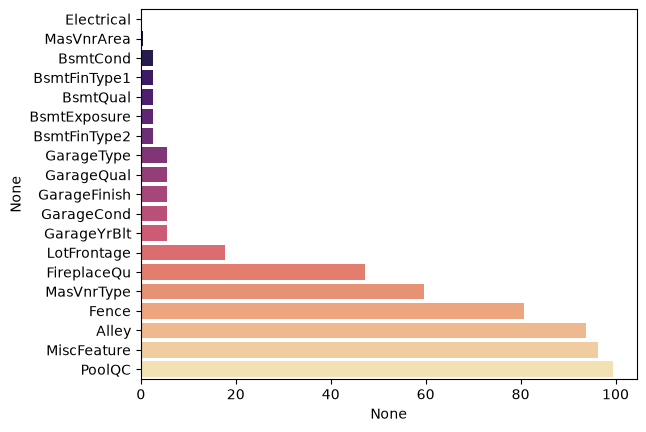

In [130]:
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [131]:
train_df['Electrical'].isnull().sum()

np.int64(1)

In [132]:
train_df['Electrical']

0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
        ...  
1455    SBrkr
1456    SBrkr
1457    SBrkr
1458    FuseA
1459    SBrkr
Name: Electrical, Length: 1460, dtype: str

In [133]:
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])

In [134]:
train_df['Electrical'].isnull().sum()

np.int64(0)

In [135]:
train_df['MasVnrArea'].value_counts()

MasVnrArea
0.0      861
180.0      8
108.0      8
72.0       8
120.0      7
        ... 
426.0      1
96.0       1
438.0      1
194.0      1
119.0      1
Name: count, Length: 327, dtype: int64

In [136]:
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)

In [137]:
train_df['MasVnrArea']

0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\3945668444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

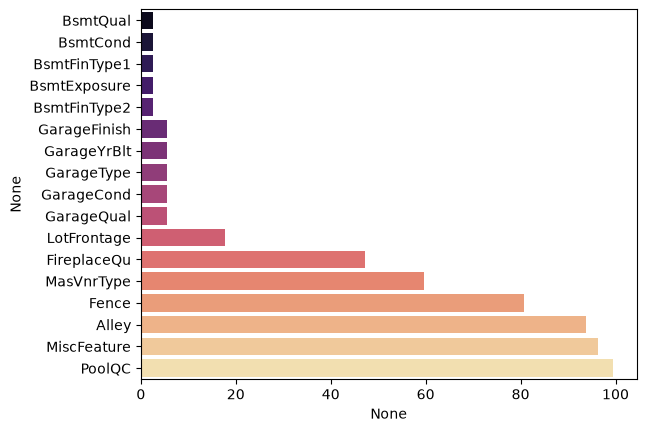

In [138]:
nan_values = missing_values(train_df)
nan_percent = (100 *(nan_values/len(train_df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [145]:
train_df[['BsmtQual','BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']]

,BsmtQual,BsmtCond,BsmtFinType1,BsmtExposure,BsmtFinType2
0,Gd,TA,GLQ,No,Unf
1,Gd,TA,ALQ,Gd,Unf
2,Gd,TA,GLQ,Mn,Unf
3,TA,Gd,ALQ,No,Unf
4,Gd,TA,GLQ,Av,Unf
...,...,...,...,...,...
1455,Gd,TA,Unf,No,Unf
1456,Gd,TA,ALQ,No,Rec
1457,TA,Gd,GLQ,No,Unf
1458,TA,TA,GLQ,Mn,Rec


In [146]:
bsm = ['BsmtQual','BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']
for i in bsm:
  print(type(i))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [ ]:
train_df[bsm] = train_df[bsm].fillna('None')

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\3945668444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

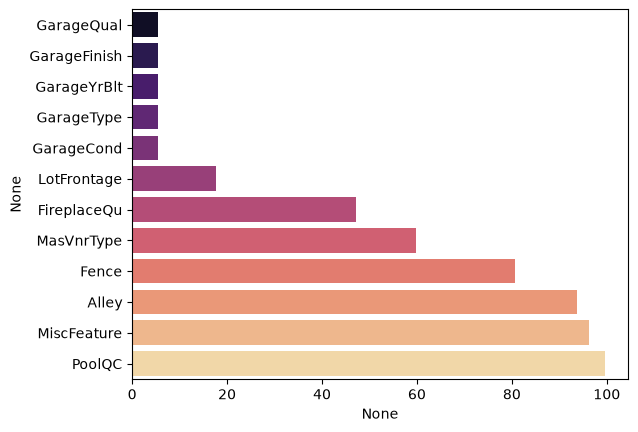

In [148]:
nan_values = missing_values(train_df)
nan_percent = (100 *(nan_values/len(train_df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [149]:
nan_values

GarageQual        81
GarageFinish      81
GarageYrBlt       81
GarageType        81
GarageCond        81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [150]:
train_df[['GarageQual', 'GarageFinish', 'GarageYrBlt', 'GarageType', 'GarageCond']]

,GarageQual,GarageFinish,GarageYrBlt,GarageType,GarageCond
0,TA,RFn,2003.0,Attchd,TA
1,TA,RFn,1976.0,Attchd,TA
2,TA,RFn,2001.0,Attchd,TA
3,TA,Unf,1998.0,Detchd,TA
4,TA,RFn,2000.0,Attchd,TA
...,...,...,...,...,...
1455,TA,RFn,1999.0,Attchd,TA
1456,TA,Unf,1978.0,Attchd,TA
1457,TA,RFn,1941.0,Attchd,TA
1458,TA,Unf,1950.0,Attchd,TA


In [159]:
garage = ['GarageQual', 'GarageFinish', 'GarageType', 'GarageCond']
train_df[garage] = train_df[garage].fillna('None')

In [160]:
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(train_df['GarageYrBlt'].mean())

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\3945668444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

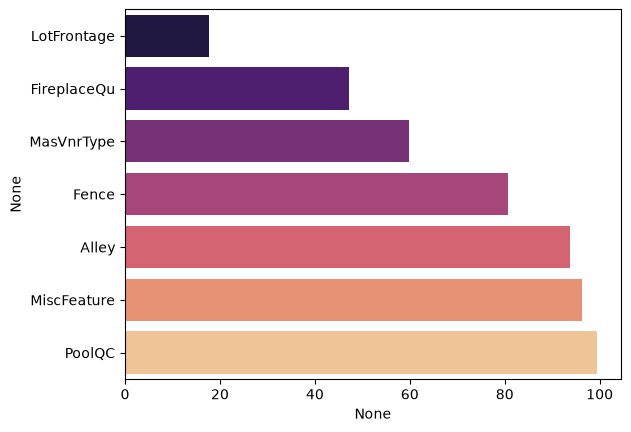

In [161]:
nan_values = missing_values(train_df)
nan_percent = (100 *(nan_values/len(train_df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [163]:
train_df['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

<Axes: ylabel='LotFrontage'>

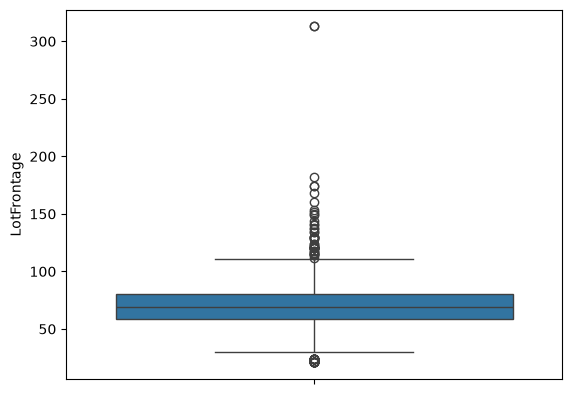

In [168]:
sns.boxplot( y = 'LotFrontage', data= train_df)

In [169]:
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\3945668444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

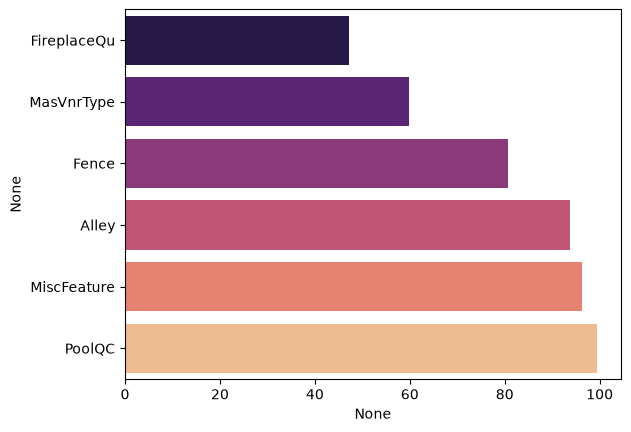

In [170]:
nan_values = missing_values(train_df)
nan_percent = (100 *(nan_values/len(train_df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [172]:
train_df['FireplaceQu']

0       NaN
1        TA
2        TA
3        Gd
4        TA
       ... 
1455     TA
1456     TA
1457     Gd
1458    NaN
1459    NaN
Name: FireplaceQu, Length: 1460, dtype: str

In [173]:
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('None')

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\3945668444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

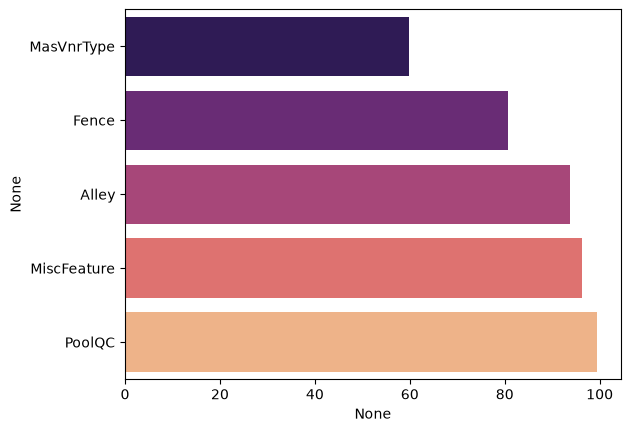

In [174]:
nan_values = missing_values(train_df)
nan_percent = (100 *(nan_values/len(train_df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [175]:
train_df['MasVnrType']

0       BrkFace
1           NaN
2       BrkFace
3           NaN
4       BrkFace
         ...   
1455        NaN
1456      Stone
1457        NaN
1458        NaN
1459        NaN
Name: MasVnrType, Length: 1460, dtype: str

In [176]:
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('None')

C:\Users\91848\AppData\Local\Temp\ipykernel_25864\3945668444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

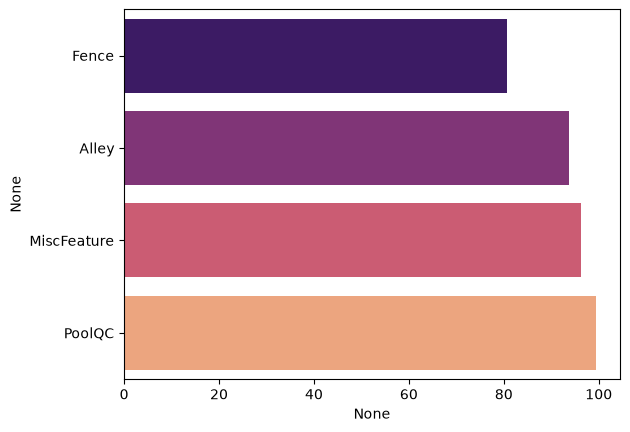

In [177]:
nan_values = missing_values(train_df)
nan_percent = (100 *(nan_values/len(train_df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [180]:
train_df = train_df.drop(['Fence', 'Alley', 'MiscFeature', 'PoolQC'], axis = 1)

In [181]:
nan_values = missing_values(train_df)
nan_values

Series([], dtype: int64)

In [186]:
train_df.isnull().sum().any()

np.False_

In [188]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460